In [22]:
import glob
import json
from os import path
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

# Copied from notebook 0001
CWD = path.join(Path().resolve())
sys.path.append(path.abspath(path.join(CWD, '..', 'trained_models')))

In [31]:
trained_model_dir = '../trained_models'
config_name = 'aramis_100ms'

val_loss_paths = glob.glob(path.join(
    trained_model_dir, 
    config_name, 
    '*', 'val_loss.txt'))
val_loss_paths.sort()

train_loss_paths = glob.glob(path.join(
    trained_model_dir, 
    config_name, 
    '*', 'train_loss.txt'))
train_loss_paths.sort()

config_paths = glob.glob(path.join(
    trained_model_dir, 
    config_name, 
    '*', 'config.json'))
config_paths.sort()

In [24]:
configs = list()
for json_path in config_paths:
    with open(json_path, 'r') as ctx:
        configs.append(json.load(ctx))

# Parameters to plot
param_names = ['WEIGHT_DECAY', 'MIN_LEARNING_RATE']
extract = lambda cfg, names: [cfg[n] for n in names]

param_values = [
    extract(c, param_names)
    for c in configs
]
param_values = np.array(param_values)

In [25]:
def best_loss(path):
    losses = np.loadtxt(path).ravel()
    return np.min(losses)

In [26]:
val_losses = [best_loss(p) for p in val_loss_paths]
val_losses = np.array(val_losses)

train_losses = [best_loss(p) for p in train_loss_paths]
train_losses = np.array(train_losses)

In [27]:
def pretty_name(param_name):
    body = param_name[1:].lower().replace('_', ' ')
    head = param_name[0].upper()
    return head + body

In [28]:
def plot_loss_against_parameter(param_idx):
    """ param_idx is the index of the parameter in param_names
    """
    fig, ax1 = plt.subplots()
    ax1.scatter(param_values[:, param_idx], val_losses, c='b', label='Best validation loss')
    ax1.scatter(param_values[:, param_idx], train_losses, c='g', label='Best training loss')
    ax1.set_xlabel(pretty_name(param_names[param_idx]))
    ax1.set_xscale('log')
    ax1.set_ylabel('Min. loss')
    ax1.legend(loc=0)

    ax2 = ax1.twinx()
    ax2.scatter(params[:, param_idx], val_losses-train_losses, c='r', label='Difference')
    ax2.legend(loc=1)

    plt.title(f'Sweeping Across 100 Values of {pretty_name(param_names[param_idx])}')
    plt.show()

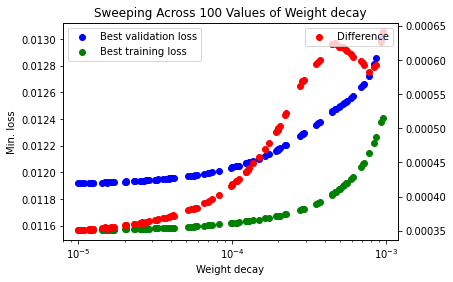

In [29]:
plot_loss_against_parameter(0)

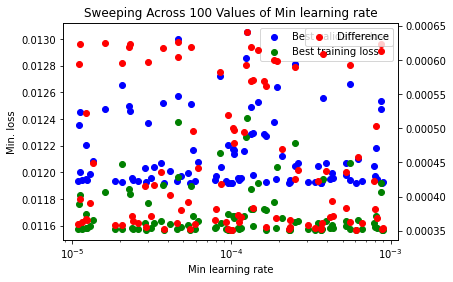

In [30]:
plot_loss_against_parameter(1)